In [1]:
#-------------------------------------------------------------------------------
# Download datatsets
#-------------------------------------------------------------------------------

import kagglehub

# Disease dataset
disease_path = kagglehub.dataset_download("adiithape1/plant-disease-detection-dataset-master-version")
print("Path to  disease dataset:", disease_path)


100%|██████████| 7.69G/7.69G [01:24<00:00, 97.9MB/s]

Extracting files...


Path to  disease dataset: /root/.cache/kagglehub/datasets/adiithape1/plant-disease-detection-dataset-master-version/versions/2


In [2]:
#-------------------------------------------------------------------------------
# Copying datasets into content/ from session's cache/
#-------------------------------------------------------------------------------
import os
import shutil

# Source directories
DISEASE_SRC = "/root/.cache/kagglehub/datasets/adiithape1/plant-disease-detection-dataset-master-version/versions/2/MasterDataset"

# Target directories
DISEASE_DST = "/content/disease_dataset"

def move_dataset(src, dst):
    if os.path.exists(dst):
        print(f"{dst} already exists. Skipping copy.")
    else:
        shutil.copytree(src, dst)
        print(f"Copied dataset to {dst}")

# Move datasets
move_dataset(DISEASE_SRC, DISEASE_DST)


Copied dataset to /content/disease_dataset


In [3]:
#-------------------------------------------------------------------------------
# Extracting the crop and disease classes.
#-------------------------------------------------------------------------------
import os

DATASET_DIR = "/content/disease_dataset"
#EXCLUDE = ["bean","cotton","bell","bell_pepper","sugarcane"]


# collect all class folders
CLASS_NAMES = sorted(os.listdir(os.path.join(DATASET_DIR, "train")))
# for i in CLASS_NAMES:
#   crop,disease = i.split("_",1)
#   if crop == "healthy" or crop == "diseased":
#      crop,disease = disease,crop
#   if crop in EXCLUDE:
#     CLASS_NAMES.remove(i)

num_classes = len(CLASS_NAMES)
print("Total classes:", num_classes)
print(CLASS_NAMES)

Total classes: 86
['apple_apple_scab', 'apple_black_rot', 'apple_cedar_apple_rust', 'bean_angular_leaf_spot', 'bean_rust', 'bell_pepper_bacterial_spot', 'cherry_powdery_mildew', 'corn_cercospora_leaf_spot', 'corn_common_rust', 'corn_gray_leaf_spot', 'corn_northern_leaf_blight', 'cotton_aphids', 'cotton_army_worm', 'cotton_bacterial_blight', 'cotton_powdery_mildew', 'cotton_target_spot', 'diseased_cucumber', 'diseased_rice', 'grape_black_rot', 'grape_esca_black_measles', 'grape_leaf_blight', 'groundnut_early_leaf_spot', 'groundnut_late_leaf_spot', 'groundnut_nutrition_deficiency', 'groundnut_rust', 'guava_anthracnose', 'guava_fruit_fly', 'healthy_apple', 'healthy_bean', 'healthy_bell_pepper', 'healthy_cherry', 'healthy_corn', 'healthy_cotton', 'healthy_cucumber', 'healthy_grape', 'healthy_groundnut', 'healthy_guava', 'healthy_lemon', 'healthy_peach', 'healthy_potato', 'healthy_pumpkin', 'healthy_rice', 'healthy_strawberry', 'healthy_sugarcane', 'healthy_tomato', 'healthy_wheat', 'lemon_

In [4]:
#-------------------------------------------------------------------------------
# Indexing classes.
#-------------------------------------------------------------------------------

class_to_index = {cls: i for i, cls in enumerate(CLASS_NAMES)}
index_to_class = {i: cls for cls, i in class_to_index.items()}

print(f"Crop to index: {class_to_index}")
print(f"Index to crop: {index_to_class}")


Crop to index: {'apple_apple_scab': 0, 'apple_black_rot': 1, 'apple_cedar_apple_rust': 2, 'bean_angular_leaf_spot': 3, 'bean_rust': 4, 'bell_pepper_bacterial_spot': 5, 'cherry_powdery_mildew': 6, 'corn_cercospora_leaf_spot': 7, 'corn_common_rust': 8, 'corn_gray_leaf_spot': 9, 'corn_northern_leaf_blight': 10, 'cotton_aphids': 11, 'cotton_army_worm': 12, 'cotton_bacterial_blight': 13, 'cotton_powdery_mildew': 14, 'cotton_target_spot': 15, 'diseased_cucumber': 16, 'diseased_rice': 17, 'grape_black_rot': 18, 'grape_esca_black_measles': 19, 'grape_leaf_blight': 20, 'groundnut_early_leaf_spot': 21, 'groundnut_late_leaf_spot': 22, 'groundnut_nutrition_deficiency': 23, 'groundnut_rust': 24, 'guava_anthracnose': 25, 'guava_fruit_fly': 26, 'healthy_apple': 27, 'healthy_bean': 28, 'healthy_bell_pepper': 29, 'healthy_cherry': 30, 'healthy_corn': 31, 'healthy_cotton': 32, 'healthy_cucumber': 33, 'healthy_grape': 34, 'healthy_groundnut': 35, 'healthy_guava': 36, 'healthy_lemon': 37, 'healthy_peach':

In [6]:
from tensorflow.keras import mixed_precision
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 128
mixed_precision.set_global_policy("mixed_float16")
tf.config.optimizer.set_jit(True)

In [7]:
#-------------------------------------------------------------------------------
# Dataset Generators.
#-------------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle = True,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle = False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)




Found 115076 files belonging to 86 classes.
Found 14356 files belonging to 86 classes.
Found 14454 files belonging to 86 classes.


In [8]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)


In [11]:
#-------------------------------------------------------------------------------
# Basic CNN Model.
#-------------------------------------------------------------------------------

from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization



model = Sequential([
    Conv2D(32, 3, padding="same", activation="relu", input_shape=(*IMG_SIZE, 3)),
    data_augmentation,
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax", dtype="float32")
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
import tensorflow as tf

class StopAtValAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, threshold=0.95, patience=2):
        super().__init__()
        self.threshold = threshold
        self.patience = patience
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        if val_acc is None:
            return

        if val_acc >= self.threshold:
            self.counter += 1
            print(f"Val acc ≥ {self.threshold} ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                print("Stopping training.")
                self.model.stop_training = True
        else:
            self.counter = 0


callbacks = [
    StopAtValAccuracy(threshold=0.95)
]

In [15]:
#-------------------------------------------------------------------------------
# Compile Model
#-------------------------------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 86)             │        22,102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,270 (583.09 KB)

 Trainable params: 148,822 (581.34 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
#-------------------------------------------------------------------------------
# Model train and test
#-------------------------------------------------------------------------------

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")


Epoch 1/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 315s 338ms/step - accuracy: 0.6079 - loss: 1.2538 - val_accuracy: 0.5500 - val_loss: 1.5524
Epoch 2/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 312s 334ms/step - accuracy: 0.7032 - loss: 0.9098 - val_accuracy: 0.4799 - val_loss: 2.2079
Epoch 3/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 292s 300ms/step - accuracy: 0.7424 - loss: 0.7692 - val_accuracy: 0.7614 - val_loss: 0.7005
Epoch 4/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 290s 322ms/step - accuracy: 0.7727 - loss: 0.6765 - val_accuracy: 0.6229 - val_loss: 1.2778
Epoch 5/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 302s 300ms/step - accuracy: 0.7894 - loss: 0.6269 - val_accuracy: 0.6546 - val_loss: 1.0832
Epoch 6/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 289s 321ms/step - accuracy: 0.8059 - loss: 0.5670 - val_accuracy: 0.8103 - val_loss: 0.5634
Epoch 7/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 273s 303ms/step - accuracy: 0.8177 - loss: 0.5317 - val_accuracy: 0.7306 - val_loss: 0.8483
Epoch 8/20
900/900 ━━━━━━━━━━━━━━━━━━━━ 275s 305ms/step - accuracy: 0.8246 -

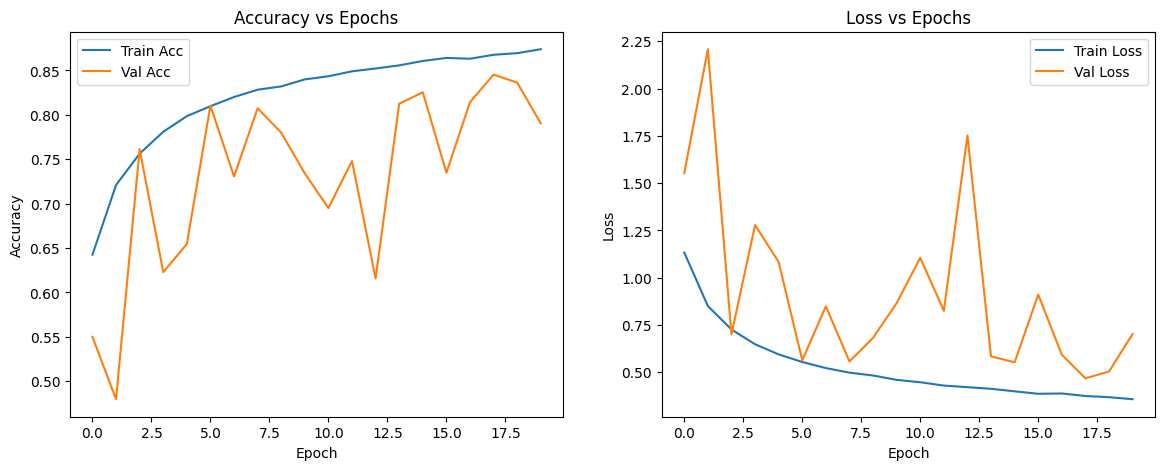

In [17]:
import matplotlib.pyplot as plt

def plot_training(history):
    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy vs Epochs")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epochs")
    plt.legend()

    plt.show()

plot_training(history)


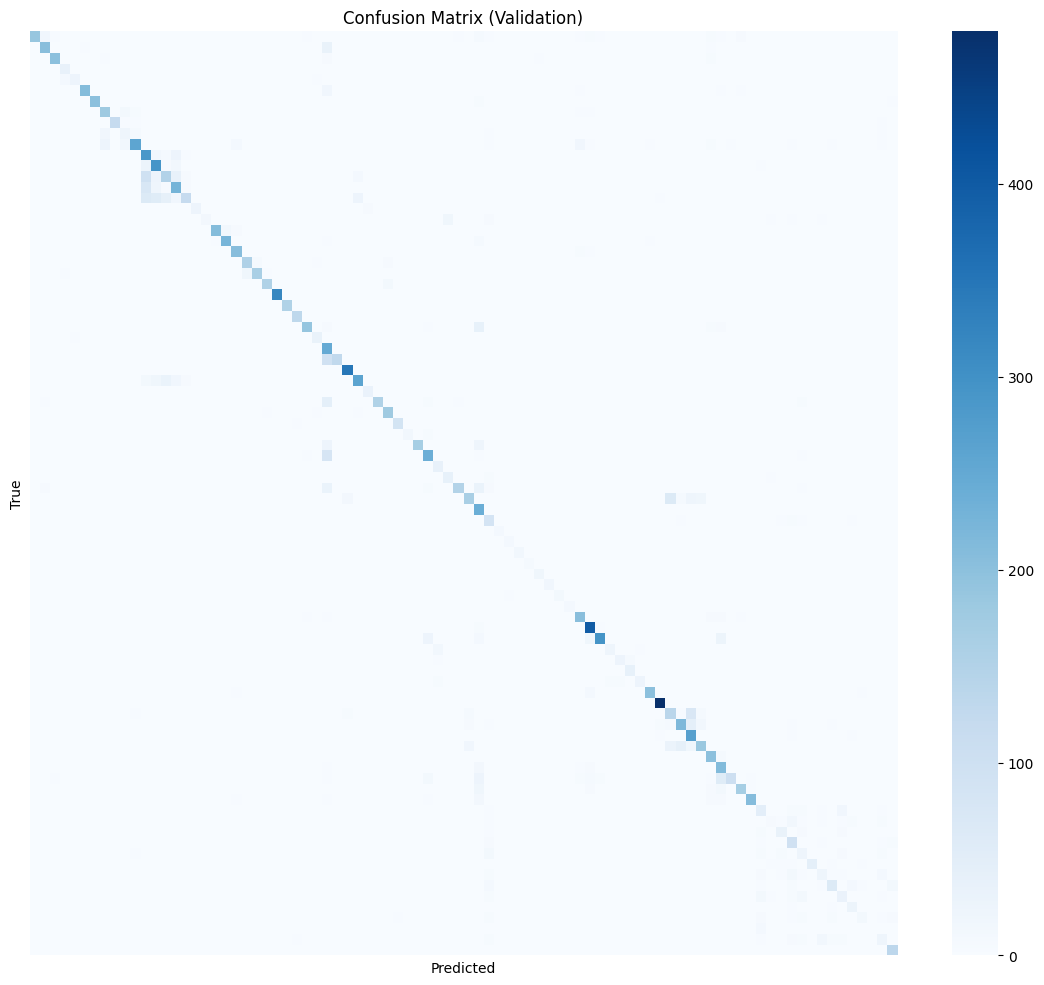

In [18]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Collect predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.show()


In [23]:
MODEL_PATH = "/content/plant_disease_cnn.keras"
model.save(MODEL_PATH)
from google.colab import files
files.download(MODEL_PATH)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>